# 🌳 Trees, Gini and more!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell.

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside this notebook.
- Answer the follow-up questions in markdown format within this notebook. A few sentences are enough; there is no length requirement.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Some questions and tasks are a bit vague. You are expected to apply techniques we learned in the lectures.
- Submit this notebook to Canvas. Deliver the notebook with its outputs saved; ideally, *restart* the kernel and then *run all*.

Good luck!

---

# 🌴 Problem 1: Fit a decision tree classifier!

### ❗️ The problem
In this first problem, you must load the data and train a decision tree classifier on the provided dataset!

### 📋 Formal requirements
1. **Implementation**:
   - Load `problem1.csv`
   - Analyse the dataset (e.g. the class distribution)
   - Preprocess the training data
   - Train a decision tree classifier
   - Implement the metrics presented in the lectures
2. **Performance**: Achieve at least **0.90** classification accuracy on the test set
3. **Discussion**:
   - What preprocessing do we need to apply before training, and why?
   - Do we need to scale the features?
   - What do you observe in the decision boundary plot before and after preprocessing?
   - What happens when you increase or decrease the depth of the tree?

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [77]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
# ====================================
# YOUR CODE GOES HERE: load the data from the problem1.csv file
data = pd.read_csv('problem1.csv')
# data.head()

# ====================================


y
0.0    930
1.0     76
Name: count, dtype: int64


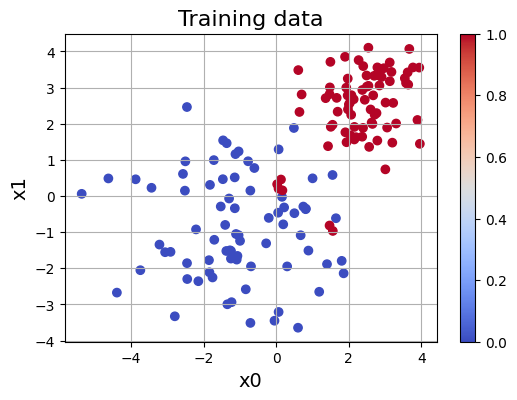

In [79]:
# ====================================
# YOUR CODE GOES HERE: let's analyse the dataset
# ====================================
train = data[data['split'] == 'train'] # Henter treningsdataene
test = data[data['split'] == 'test'] # Henter testdataene

print(train['y'].value_counts()) # Sjekker fordelingen av klasser i treningsdataene

class_0 = train[train['y'] == 0] # Henter alle datapunkter i klasse 0
class_1 = train[train['y'] == 1] # Henter alle datapunkter i klasse 1

class_0_under = class_0.sample(n=len(class_1), random_state=42) # Trekker like mange fra klasse 0 som vi har i klasse 1

train = pd.concat([class_0_under, class_1]) # Lager nytt balansert treningssett, undersampling klasse 0


# ====================================
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Training data', fontsize=16)
plt.colorbar()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train = train[['x0', 'x1']]
y_train = train['y']
X_test = test[['x0', 'x1']]
y_test = test['y']

# ====================================
# YOUR CODE GOES HERE
clf = DecisionTreeClassifier(max_depth=2, random_state=42) # Lager beslutningstreet og setter max_depth til 2
clf.fit(X_train, y_train) # Trener treet på treningsdataene

y_pred = clf.predict(X_test) # Predikerer klassene til testdataene
accuracy = accuracy_score(y_test, y_pred) # Regner ut accuracy

# ==================================

# ====================================
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.90


In [81]:
# ====================================
# YOUR CODE GOES HERE: report FPR and TPR alongside other metrics you find relevant (hint: see the lecture notes).
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel() # Henter TN, FP, FN og TP

tpr = tp / (tp + fn) # True Positive Rate = andel faktiske positive som modellen finner
fpr = fp / (fp + tn) # False Positive Rate = andel faktiske negative som feilaktig blir positive
tnr = tn / (tn + fp) # True Negative Rate / specificity
precision = tp / (tp + fp) # Precision / PPV
# ====================================

# ====================================
print(f"True positive rate: {tpr:.3f}")
print(f"False positive rate: {fpr:.3f}")
print(f"True negative rate: {tnr:.3f}")
print(f"Precision: {precision:.3f}")

True positive rate: 0.967
False positive rate: 0.160
True negative rate: 0.840
Precision: 0.858


### ❓ What preprocessing do we need to apply before training, and why?


Preprosessering er nødvendig fordi treningsdataene er svært ubalanserte. Omtrent 92 % av datapunktene tilhører klasse 0, mens bare omtrent 8 % tilhører klasse 1. Uten preprosessering kan modellen derfor bli dominert av majoritetsklassen. Jeg brukte derfor undersampling for å balansere klassene før trening.

### ❓ Do we need to scale the features?

Nei, beslutningstrær trenger ikke featureskalering. Treet splitter dataene ved å sammenligne én feature om gangen med en terskelverdi, så det er ikke nødvendig at featurene har samme størrelsesorden. Skalering vil derfor normalt ikke endre hvilke splitter treet velger.

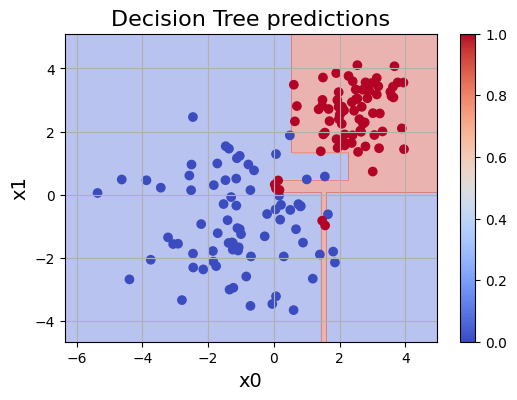

In [82]:
# visualize the decision boundary
x0_min, x0_max = train['x0'].min() - 1, train['x0'].max() + 1
x1_min, x1_max = train['x1'].min() - 1, train['x1'].max() + 1
xx0, xx1 = np.meshgrid(np.arange(x0_min, x0_max, 0.01),
                       np.arange(x1_min, x1_max, 0.01))

grid = pd.DataFrame({'x0': xx0.ravel(), 'x1': xx1.ravel()})
Z = clf.predict(grid)
Z = Z.reshape(xx0.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx0, xx1, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_train['x0'], X_train['x1'], c=y_train, cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Decision Tree predictions', fontsize=16)
plt.colorbar()
plt.show()

### ❓ What do you observe in the decision boundary plot before and after preprocessing?


Før preprosessering er treningsdataene sterkt dominert av klasse 0 (blå). Det ser vi også i beslutningsgrensen: modellen predikerer klasse 0 i store deler av området, mens klasse 1 bare får små og ganske oppstykkede områder.

Etter undersampling er klassene balansert i treningsdataene. Da får klasse 1 et mye større og mer sammenhengende beslutningsområde, spesielt rundt klyngen øverst til høyre. Modellen blir dermed bedre til å fange opp minoritetsklassen, noe som også samsvarer med at accuracy økte fra 0,69 til 0,90.

Ulempen er at undersampling fjerner mange datapunkter fra klasse 0, så modellen trener på mindre data.

### ❓ What happens when you increase or decrease the depth of the tree?


Prøvde ulike max-depths og fikk resultater: 
max_depth 1-accuracy: 0.88, TPR:0.92, FPR:0.167, TNR:0.822, Precision:0.847
max_depth 2- accuracy: 0.91, TPR:0.92, FPR:0.107, TNR:0.893, Precision:0.896
max_depth 3- accuracy: 0.91, TPR:1, FPR:0.173, TNR:0.827, Precision:0.852
max_depth 5- accuracy: 0.9, TPR:0.967, FPR:0.160, TNR:0.84, Precision:0.858
max_depth 10- accuracy: 0.9, TPR:0.967, FPR:0.160, TNR:0.84, Precision:0.858

Når max_depth øker, kan beslutningstreet lage flere splitter og dermed mer komplekse beslutningsgrenser. Ved lav dybde er modellen enkel og kan undertilpasse, mens større dybde gjør at modellen tilpasser seg treningsdataene mer detaljert og kan overtilpasse. Jeg valgte max_depth = 2, fordi denne ga høy accuracy (0.91), lavest FPR (0.107) og høy precision (0.896), samtidig som modellen fortsatt er relativt enkel.

# 🌴🌴 Problem 2: Predict Viking voyage survivors 🗡️
### ❗️ The problem
You are given a dataset with information about the passengers on Viking voyages.
Your task is to develop a decision tree classifier that predicts which Vikings **survived** a **voyage**.

### 📋 Formal requirements
1. **Implementation**:
   - Do a simple data analysis
   - Preprocess the data 
   - Train a decision tree classifier
   - Report the cross-validation score and the test accuracy
   - Try different split criteria for the decision tree
   - Plot the decision tree
   - Use a boosting technique to improve the accuracy!
   - Use Naïve Bayes to predict whether a single new voyager survives
2. **Performance**: Achieve at least **0.80** classification accuracy on the test set
3. **Discussion**:
   - Analyse the dataset. Are there any features that already predict survival better than a random guess?
   - What is the purpose of cross-validation?
   - Which split criterion do you prefer, and why?
   - What is Gini impurity? Use an example from the decision tree graph you created
   - Which terms of Bayes theorem can you estimate from this dataset, and which ones are difficult?
   - Use Naïve Bayes: does the new voyager have a higher or lower chance of surviving?

In [83]:
df = pd.read_csv('problem2.csv')

Let's start by understanding the dataset.

In [84]:
# Let's analyse the dataset
# Make some comments about what you print and what useful information it gives
# ====================================
# YOUR CODE GOES HERE: Let's analyse the dataset!
# ====================================

# ====================================
print(f"Female survival rate: {rate_female:.1%}")
print(f"Male survival rate: {rate_male:.1%}")

NameError: name 'rate_female' is not defined

### ❓ Are there any features that already predict survival better than a random guess?


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
target = 'survived'
# ====================================
# YOUR CODE GOES HERE: Train the model:)
# ====================================

# ====================================
print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Test accuracy: {a:.4f}")

### ❓ What is the purpose of cross validation?


In [ ]:
# Compare the different split criteria
# ====================================
# YOUR CODE GOES HERE: try the different split criteria (gini, entropy, log_loss)
# and report the cross-validation and test accuracy for each
# ====================================


### ❓ Try different DecisionTreeClassifier criteria, report what accuracy you get. Which criterion do you prefer?


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# ====================================
# YOUR CODE GOES HERE: Plot the decision tree nodes!
# ====================================


### ❓ What is Gini? Use an example from the decision tree graph you created.


## Improving the results with boosting 🚀

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
# ====================================
# YOUR CODE GOES HERE: Use AdaBoostClassifier to get even better results!
# ====================================

# ====================================
ada_acc = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost CV Accuracy: {ada_cv_scores.mean():.3f} ± {ada_cv_scores.std():.3f}")
print(f"AdaBoost test accuracy: {ada_acc:.4f}")

### ❓ Try estimating the factors of Bayes theorem using this dataset. What terms can you estimate and which ones are difficult and why?
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

In [ ]:
# ====================================
# YOUR CODE GOES HERE: estimate the terms of Bayes theorem you can
# ====================================


### ❓ Use Naïve Bayes. Does Endre have a higher or lower chance of surviving than dying on a voyage?

A voyager named **Endre** is about to set sail. This is what we know about him:

| Feature | Value |
| --- | --- |
| `sex` | Male |
| `age` | 25 |
| `role` | Hirdman |
| `ship` | Drakvinge |
| `destination` | Normandy |
| `clan_origin` | Nidaros |
| `armor` | Chainmail |
| `provisions_kg` | 49 |
| `family_aboard` | 2 |
| `prior_voyages` | 12 |

Does he have a **higher or lower** chance of surviving the voyage?

In [ ]:
# ====================================
# YOUR CODE GOES HERE: Naïve Bayes
# You can either do this by hand or with code.
# Do not import libraries.
# ====================================
